<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab08/lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning HerBERT do analizy sentymentu
## Pipeline: Hugging Face → Tokenizacja → Fine-tuning (Trainer API) → Porównanie z klasycznym ML

**Dataset:** PolEmo 2.0 — ten sam zbiór co na laboratorium 7. Pozwoli to na **bezpośrednie porównanie** podejścia klasycznego (TF-IDF + SVM/LogReg/NB) z podejściem opartym na transformerze (HerBERT).

**Model:** `allegro/herbert-base-cased` — polski BERT od Allegro, pre-trenowany na korpusie ok. 1,8 mld tokenów polskich tekstów
(National Corpus of Polish, Polska Wikipedia, Open Subtitles,
Wolne Lektury, Allegro Articles)

**Etykiety sentymentu (jak w lab. 7):**
- `minus` — negatywny
- `zero` — neutralny
- `plus` — pozytywny
- `amb` — ambiwalentny

> **⚠️ Uwaga o środowisku:** Ten notatnik wymaga GPU. Przed uruchomieniem zmień typ środowiska wykonawczego Colab: **Środowisko wykonawcze → Zmień typ środowiska wykonawczego → T4 GPU**. Na CPU fine-tuning trwałby kilka godzin zamiast ~10 minut.

# 1. Instalacja i import bibliotek

W porównaniu do lab. 7 potrzebujemy dodatkowo:
- `transformers` — główna biblioteka Hugging Face
- `datasets` — ładowanie i tokenizacja zbiorów
- `accelerate` — wspomaga trening (wymaga `Trainer` w nowszych wersjach)
- `evaluate` (opcjonalnie) — biblioteka metryk HF

In [43]:
# Instalacja pakietów HF (cicho, żeby nie zaśmiecać wyjścia)
!pip install -q transformers datasets accelerate evaluate

In [44]:
# Weryfikacja dostępności GPU
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA dostępna: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Pamięć GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ GPU nieaktywne — trening będzie bardzo wolny!")
    print("Przełącz środowisko: Runtime → Change runtime type → T4 GPU")

PyTorch: 2.10.0+cu128
CUDA dostępna: True
GPU: Tesla T4
Pamięć GPU: 15.6 GB


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
)

# Ustalenie ziarna dla powtarzalności
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Wszystkie biblioteki załadowane pomyślnie ✓")

Wszystkie biblioteki załadowane pomyślnie ✓


# 2. Ładowanie datasetu PolEmo 2.0

Używamy **dokładnie tego samego** datasetu co na lab. 7 — `allegro/klej-polemo2-in`. Dzięki temu możemy bezpośrednio porównać wyniki obu podejść.

Dataset ma już gotowy podział na `train` / `validation` / `test`.

In [46]:
# Ładowanie datasetu z Hugging Face Hub
dataset = load_dataset("allegro/klej-polemo2-in")

print("Struktura datasetu:")
print(dataset)
print()
print("Przykładowy rekord:")
print(dataset['train'][0])

Struktura datasetu:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'target'],
        num_rows: 5783
    })
    validation: Dataset({
        features: ['sentence', 'target'],
        num_rows: 723
    })
    test: Dataset({
        features: ['sentence', 'target'],
        num_rows: 722
    })
})

Przykładowy rekord:
{'sentence': 'Super lekarz i człowiek przez duże C . Bardzo duże doświadczenie i trafne diagnozy . Wielka cierpliwość do ludzi starszych . Od lat opiekuje się moją Mamą staruszką , i twierdzę , że mamy duże szczęście , że mamy takiego lekarza . Naprawdę nie wiem cobyśmy zrobili , gdyby nie Pan doktor . Dzięki temu , moja mama żyje . Każda wizyta u specjalisty jest u niego konsultowana i uważam , że jest lepszy od każdego z nich . Mamy do Niego prawie nieograniczone zaufanie . Można wiele dobrego o Panu doktorze jeszcze napisać . Niestety , ma bardzo dużo pacjentów , jest przepracowany ( z tego powodu nawet obawiam się o jego zdrowie ) i dostęp do niego 

In [47]:
# Sprawdzenie etykiet
df_peek = pd.DataFrame(dataset['train'])
print("Unikatowe wartości 'target':", df_peek['target'].unique())
print()
print("Rozkład klas w zbiorze treningowym:")
print(df_peek['target'].value_counts())

Unikatowe wartości 'target': ['__label__meta_plus_m' '__label__meta_minus_m' '__label__meta_amb'
 '__label__meta_zero']

Rozkład klas w zbiorze treningowym:
target
__label__meta_minus_m    2194
__label__meta_plus_m     1568
__label__meta_amb        1050
__label__meta_zero        971
Name: count, dtype: int64


## 2.1. Mapowanie etykiet tekstowych na liczby

HerBERT (jak każdy model klasyfikacyjny w `transformers`) oczekuje **numerycznych** etykiet w kolumnie `labels`. Musimy więc przemapować wartości tekstowe (`minus`, `zero`, `plus`, `amb`) na liczby całkowite.

Używamy ustalonej, deterministycznej kolejności, żeby mieć pełną kontrolę — i żeby zapamiętać mapowanie do późniejszej predykcji.

In [48]:
# UWAGA: dataset allegro/klej-polemo2-in używa etykiet w formacie
#   '__label__meta_plus_m', '__label__meta_minus_m', '__label__meta_zero', '__label__meta_amb'
# (w starszych wersjach bywały też skrócone: 'plus', 'minus', 'zero', 'amb').
# Żeby notatnik działał niezależnie od wersji, wykrywamy etykiety z danych.

# Skrócone nazwy (kanoniczne) → polska nazwa czytelna
label_names_pl = {
    'minus': 'negatywny',
    'zero':  'neutralny',
    'plus':  'pozytywny',
    'amb':   'ambiwalentny',
}

def short_label(raw_label: str) -> str:
    """Normalizacja: '__label__meta_plus_m' → 'plus', 'plus' → 'plus'."""
    for key in label_names_pl:
        if key in raw_label:
            return key
    raise ValueError(f"Nieznana etykieta: {raw_label!r}")

# Ustalona kolejność klas (dzięki temu id są deterministyczne)
canonical_order = ['minus', 'zero', 'plus', 'amb']

# Jakie etykiety faktycznie występują w danych?
raw_labels_in_data = sorted(set(dataset['train']['target']))

# raw (tak jak w datasecie) → short (kanoniczne) → id
raw2short = {raw: short_label(raw) for raw in raw_labels_in_data}
short2id = {lbl: idx for idx, lbl in enumerate(canonical_order) if lbl in raw2short.values()}

# Mapowania używane dalej w notatniku
label2id = {raw: short2id[raw2short[raw]] for raw in raw_labels_in_data}
id2label = {idx: lbl for lbl, idx in short2id.items()}  # id → short label (np. 'plus')
label_list = [id2label[i] for i in sorted(id2label)]    # uporządkowana lista short labels

print("Mapowanie etykiet (raw → short → id):")
for raw in raw_labels_in_data:
    short = raw2short[raw]
    idx = label2id[raw]
    print(f"  {raw!r:35s} → {short!r:8s} ({label_names_pl[short]:>13s}) → id={idx}")
print()
print(f"label_list (kanoniczne): {label_list}")
print(f"id2label: {id2label}")

Mapowanie etykiet (raw → short → id):
  '__label__meta_amb'                 → 'amb'    ( ambiwalentny) → id=3
  '__label__meta_minus_m'             → 'minus'  (    negatywny) → id=0
  '__label__meta_plus_m'              → 'plus'   (    pozytywny) → id=2
  '__label__meta_zero'                → 'zero'   (    neutralny) → id=1

label_list (kanoniczne): ['minus', 'zero', 'plus', 'amb']
id2label: {0: 'minus', 1: 'zero', 2: 'plus', 3: 'amb'}


In [49]:
# Dodajemy kolumnę 'labels' (numeryczną) — wymaganą przez Trainer API
def map_labels(example):
    example['labels'] = label2id[example['target']]
    return example

dataset = dataset.map(map_labels)

print("Dataset po dodaniu kolumny 'labels':")
print(dataset)
print()
print("Przykład:")
print(dataset['train'][0])

Dataset po dodaniu kolumny 'labels':
DatasetDict({
    train: Dataset({
        features: ['sentence', 'target', 'labels'],
        num_rows: 5783
    })
    validation: Dataset({
        features: ['sentence', 'target', 'labels'],
        num_rows: 723
    })
    test: Dataset({
        features: ['sentence', 'target', 'labels'],
        num_rows: 722
    })
})

Przykład:
{'sentence': 'Super lekarz i człowiek przez duże C . Bardzo duże doświadczenie i trafne diagnozy . Wielka cierpliwość do ludzi starszych . Od lat opiekuje się moją Mamą staruszką , i twierdzę , że mamy duże szczęście , że mamy takiego lekarza . Naprawdę nie wiem cobyśmy zrobili , gdyby nie Pan doktor . Dzięki temu , moja mama żyje . Każda wizyta u specjalisty jest u niego konsultowana i uważam , że jest lepszy od każdego z nich . Mamy do Niego prawie nieograniczone zaufanie . Można wiele dobrego o Panu doktorze jeszcze napisać . Niestety , ma bardzo dużo pacjentów , jest przepracowany ( z tego powodu nawet obawiam si

# 3. Pipeline API — szybki baseline bez fine-tuningu

Zanim zaczniemy fine-tuning, sprawdźmy co potrafi **gotowy** polski model sentymentu z HF Hub. Pipeline API to najwyższy poziom abstrakcji w `transformers` — kilka linijek kodu i mamy działający klasyfikator.

Użyjemy modelu `Voicelab/herbert-base-cased-sentiment` (wariant HerBERT fine-tunowany przez Voicelab).

In [50]:
# Pipeline dla analizy sentymentu
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="Voicelab/herbert-base-cased-sentiment",
    device=0 if torch.cuda.is_available() else -1,  # GPU jeśli dostępne
)

# Szybki test na przykładowych zdaniach
przyklady = [
    "Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam gorąco!",
    "Hotel był brudny, jedzenie okropne, nigdy więcej.",
    "Wizyta u lekarza przebiegła bez problemów, nic szczególnego.",
]

wyniki = sentiment_pipe(przyklady)
for tekst, wynik in zip(przyklady, wyniki):
    print(f"[{wynik['label']:>10s} {wynik['score']:.3f}]  {tekst}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: Voicelab/herbert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[  positive 0.999]  Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam gorąco!
[  negative 0.992]  Hotel był brudny, jedzenie okropne, nigdy więcej.
[  positive 0.998]  Wizyta u lekarza przebiegła bez problemów, nic szczególnego.


**Uwaga:** Model `Voicelab/herbert-base-cased-sentiment` ma własny zestaw etykiet (`POSITIVE`/`NEGATIVE`/`NEUTRAL`, bez `ambiwalentnego`), więc **nie jest bezpośrednio porównywalny** z naszym zadaniem czteroklasowym. Dlatego w kolejnych sekcjach fine-tunujemy HerBERT-a **od początku** na naszych etykietach.

To podkreśla kluczową decyzję projektową: **gotowy pipeline** vs **własny fine-tuning**.
- Gotowy pipeline: zero pracy, ale etykiety są takie, jakie ktoś inny wybrał.
- Fine-tuning: kontrola nad etykietami i dopasowanie do **konkretnej** dystrybucji danych.

# 4. Tokenizacja danych

**Tokenizer** rozkłada tekst na tokeny ze słownika modelu (HerBERT używa BPE). Następnie zamienia tokeny na identyfikatory liczbowe (`input_ids`), dodaje specjalne tokeny początku i końca sekwencji oraz maski uwagi
(attention_mask). HerBERT bazuje na architekturze RoBERTa, więc używa
tokenów `<s>` (odpowiednik `[CLS]`) i `</s>` (odpowiednik `[SEP]`) zamiast
klasycznych tokenów BERT-a.

Kluczowe parametry:
- `max_length` — maksymalna długość sekwencji (HerBERT: limit 512 tokenów wynika z uczonego kodowania pozycyjnego)
- `truncation=True` — obcinamy dłuższe teksty
- `padding` — dopełnianie do jednakowej długości. Użyjemy **dynamic padding** przez `DataCollatorWithPadding` (szybsze niż padding do `max_length` już na etapie tokenizacji)

In [51]:
MODEL_NAME = "allegro/herbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {type(tokenizer).__name__}")
print(f"Rozmiar słownika: {tokenizer.vocab_size}")
print(f"Specjalne tokeny: CLS={tokenizer.cls_token}, SEP={tokenizer.sep_token}, "
      f"PAD={tokenizer.pad_token}, UNK={tokenizer.unk_token}, MASK={tokenizer.mask_token}")

Tokenizer: HerbertTokenizer
Rozmiar słownika: 50000
Specjalne tokeny: CLS=<s>, SEP=</s>, PAD=<pad>, UNK=<unk>, MASK=<mask>


In [52]:
# Zobaczmy, jak tokenizer dzieli przykładowe zdanie
przyklad = "Ten film był naprawdę zaskakująco dobry!"
tokeny = tokenizer.tokenize(przyklad)
print(f"Zdanie: {przyklad}")
print(f"Tokeny ({len(tokeny)}): {tokeny}")
print()

# Pełny wynik tokenizacji
out = tokenizer(przyklad, return_tensors="pt")
print("Pełny wynik (keys):", list(out.keys()))
print("input_ids:", out['input_ids'])
print("attention_mask:", out['attention_mask'])
print()
print("Dekodowanie z powrotem:", tokenizer.decode(out['input_ids'][0]))

Zdanie: Ten film był naprawdę zaskakująco dobry!
Tokeny (8): ['Ten</w>', 'film</w>', 'był</w>', 'naprawdę</w>', 'zaskak', 'ująco</w>', 'dobry</w>', '!</w>']

Pełny wynik (keys): ['input_ids', 'attention_mask']
input_ids: tensor([[    0,  4847,  6956,  2430,  4728, 15255, 11675,  6092,  1725,     2]])
attention_mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

Dekodowanie z powrotem: <s>Ten film był naprawdę zaskakująco dobry ! </s>


## 4.1. Analiza długości sekwencji

Zanim ustalimy `max_length`, warto sprawdzić, jak długie są recenzje w PolEmo 2.0 **po tokenizacji HerBERT-em**. Zbyt duże `max_length` to strata czasu i pamięci GPU; zbyt małe odcina ważny kontekst z końców recenzji.

Token indices sequence length is longer than the specified maximum sequence length for this model (560 > 512). Running this sequence through the model will result in indexing errors


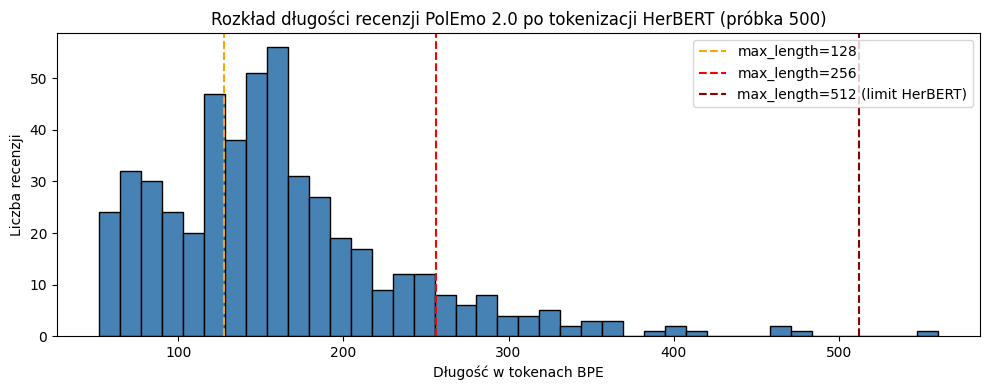

Statystyki długości (n=500):
  min=52, max=560, mean=160.2, median=150, 95%=305


In [53]:
# Rozkład długości w tokenach (na próbce, bo cały zbiór to dłużej)
sample_texts = dataset['train']['sentence'][:500]
lengths = [len(tokenizer.encode(t, truncation=False)) for t in sample_texts]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=40, color='steelblue', edgecolor='black')
ax.axvline(128, color='orange', linestyle='--', label='max_length=128')
ax.axvline(256, color='red', linestyle='--', label='max_length=256')
ax.axvline(512, color='darkred', linestyle='--', label='max_length=512 (limit HerBERT)')
ax.set_xlabel('Długość w tokenach BPE')
ax.set_ylabel('Liczba recenzji')
ax.set_title('Rozkład długości recenzji PolEmo 2.0 po tokenizacji HerBERT (próbka 500)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Statystyki długości (n={len(lengths)}):")
print(f"  min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}, "
      f"median={np.median(lengths):.0f}, 95%={np.percentile(lengths, 95):.0f}")

Na podstawie rozkładu dobieramy `max_length=256` jako kompromis:
- pokrywa większość recenzji bez obcinania,
- jest 2× szybszy niż `max_length=512`,
- mieści się w pamięci GPU T4 z batch_size=16.

In [54]:
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

# map() z batched=True przetwarza po grupach przykładów — znacznie szybsze
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["sentence", "target"],  # usuwamy oryginalne kolumny tekstowe
)

print("Dataset po tokenizacji:")
print(tokenized_dataset)
print()
print("Przykładowy rekord:")
print({k: (v[:20] if isinstance(v, list) and len(v) > 20 else v)
       for k, v in tokenized_dataset['train'][0].items()})

Map:   0%|          | 0/5783 [00:00<?, ? examples/s]

Map:   0%|          | 0/723 [00:00<?, ? examples/s]

Map:   0%|          | 0/722 [00:00<?, ? examples/s]

Dataset po tokenizacji:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5783
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 723
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 722
    })
})

Przykładowy rekord:
{'labels': 2, 'input_ids': [0, 24607, 9328, 1009, 5469, 2188, 5458, 1023, 1899, 5162, 5458, 10376, 1009, 5462, 2079, 44828, 1899, 10677, 27232, 2041], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [55]:
# Data collator — dynamiczne paddowanie do najdłuższej sekwencji w batchu
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 5. Ładowanie modelu z głową klasyfikacyjną

`AutoModelForSequenceClassification` ładuje pre-trenowany HerBERT i dokłada losowo zainicjalizowaną głowę klasyfikacyjną na reprezentacji
pierwszego tokenu (`<s>`). W modelach RoBERTa-like głowa to moduł
RobertaClassificationHead zawierający dwie warstwy liniowe (dense + out_proj)
rozdzielone aktywacją tanh i dropoutem — nie pojedynczą warstwę liniową.

Kluczowe argumenty:
- `num_labels=4` — cztery klasy sentymentu
- `id2label` / `label2id` — zapisywane w konfiguracji modelu; dzięki temu po załadowaniu modelu wiadomo, co oznaczają poszczególne etykiety.

In [56]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

# Liczba parametrów
n_params_total = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Liczba parametrów (łącznie):    {n_params_total:,}")
print(f"Liczba parametrów (trenowanych): {n_params_trainable:,}")
print(f"Rozmiar na dysku: ~{n_params_total * 4 / 1e6:.0f} MB (float32)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly in

Model: allegro/herbert-base-cased
Liczba parametrów (łącznie):    124,445,956
Liczba parametrów (trenowanych): 124,445,956
Rozmiar na dysku: ~498 MB (float32)


Głowa klasyfikacyjna (`classifier.weight`, `classifier.bias`) jest **świeża**, bo pre-trenowany model jej nie miał. Dlatego przed użyciem musimy go fine-tunować.

# 6. Funkcja metryk

`Trainer` wywoła tę funkcję po każdej ewaluacji. Dostaje tuple `(logits, labels)` i zwraca słownik z metrykami.

Używamy tych samych metryk co w lab. 7 — **accuracy** i **F1 macro** — żeby wyniki były bezpośrednio porównywalne.

In [57]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions,
        average='macro',
        zero_division=0,
    )
    acc = accuracy_score(labels, predictions)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": f1,
        "f1_weighted": f1_weighted,
        "precision_macro": precision,
        "recall_macro": recall,
    }

# 7. Konfiguracja treningu — TrainingArguments

`TrainingArguments` to klasa konfiguracyjna zawierająca **wszystkie** hiperparametry treningu. Najważniejsze:

- **`learning_rate=2e-5`** — typowa wartość dla fine-tuningu BERT. Nie stosujemy wartości z treningu od zera (`1e-3`), bo model już „zna" język — chcemy tylko delikatnie dostroić wagi.
- **`num_train_epochs=3`** — dla fine-tuningu BERT zwykle wystarczają 2–4 epoki. Więcej → overfitting.
- **`per_device_train_batch_size=16`** — dobrany tak, żeby zmieścić się w 16 GB pamięci T4.
- **`warmup_steps`** — na początku treningu lr stopniowo rośnie od 0 do docelowej wartości; stabilizuje trening BERT.
- **`weight_decay=0.01`** — regularyzacja L2, standardowa dla AdamW.
- **`fp16=True`** — mixed precision (float16 + float32) — 2× szybszy trening, mniej pamięci, prawie taka sama jakość.
- **`eval_strategy="epoch"`** — ewaluacja po każdej epoce.
- **`load_best_model_at_end=True`** — po treningu załadujemy checkpoint, który dał najlepszy wynik na walidacji, niezależnie od tego czy był to ostatni.

In [58]:
training_args = TrainingArguments(
    output_dir="./herbert-polemo",

    # Hiperparametry treningu
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,            # 10% pierwszych kroków to warmup
    weight_decay=0.01,

    # Strategia ewaluacji i zapisu
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,          # zachowaj maksymalnie 2 checkpointy (oszczędzamy dysk Colab)
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    # Wydajność
    fp16=torch.cuda.is_available(),  # mixed precision tylko na GPU
    dataloader_num_workers=2,

    # Logowanie
    logging_steps=50,
    report_to="none",            # wyłączamy W&B/TensorBoard, żeby nie prosić o zalogowanie

    seed=SEED,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [59]:
import inspect
_trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
if 'processing_class' in inspect.signature(Trainer.__init__).parameters:
    _trainer_kwargs['processing_class'] = tokenizer   # transformers >= 4.46
else:
    _trainer_kwargs['tokenizer'] = tokenizer          # transformers < 4.46

trainer = Trainer(**_trainer_kwargs)

print("Trainer gotowy. Zaraz uruchomimy trening.")
print(f"Liczba przykładów treningowych:  {len(tokenized_dataset['train'])}")
print(f"Liczba przykładów walidacyjnych: {len(tokenized_dataset['validation'])}")
print(f"Liczba przykładów testowych:     {len(tokenized_dataset['test'])}")

Trainer gotowy. Zaraz uruchomimy trening.
Liczba przykładów treningowych:  5783
Liczba przykładów walidacyjnych: 723
Liczba przykładów testowych:     722


## 7.1. Uruchomienie treningu

Trening na T4 GPU zajmie **około 8–12 minut**. Trainer pokaże tabelę z metrykami po każdej epoce.

Na CPU to zajmie godzinami — **nie uruchamiaj** bez GPU.

In [60]:
# Trening!
train_result = trainer.train()

# Podsumowanie treningu
print("\n" + "=" * 60)
print("TRENING ZAKOŃCZONY")
print("=" * 60)
print(f"Czas treningu: {train_result.metrics['train_runtime']:.1f} s "
      f"({train_result.metrics['train_runtime']/60:.1f} min)")
print(f"Steps/s: {train_result.metrics.get('train_steps_per_second', 0):.2f}")
print(f"Finalna strata treningowa: {train_result.metrics['train_loss']:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,0.341808,0.300925,0.881051,0.855511,0.877045,0.860930,0.852921
2,0.248405,0.298302,0.893499,0.868449,0.888362,0.878878,0.863776
3,0.155620,0.346424,0.896266,0.880372,0.896605,0.878448,0.882469


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


TRENING ZAKOŃCZONY
Czas treningu: 316.2 s (5.3 min)
Steps/s: 3.44
Finalna strata treningowa: 0.3365


## 7.2. Wizualizacja postępu treningu

`Trainer` zapisuje historię strat i metryk w `trainer.state.log_history`. Narysujmy przebieg straty treningowej i metryk walidacyjnych po epokach.

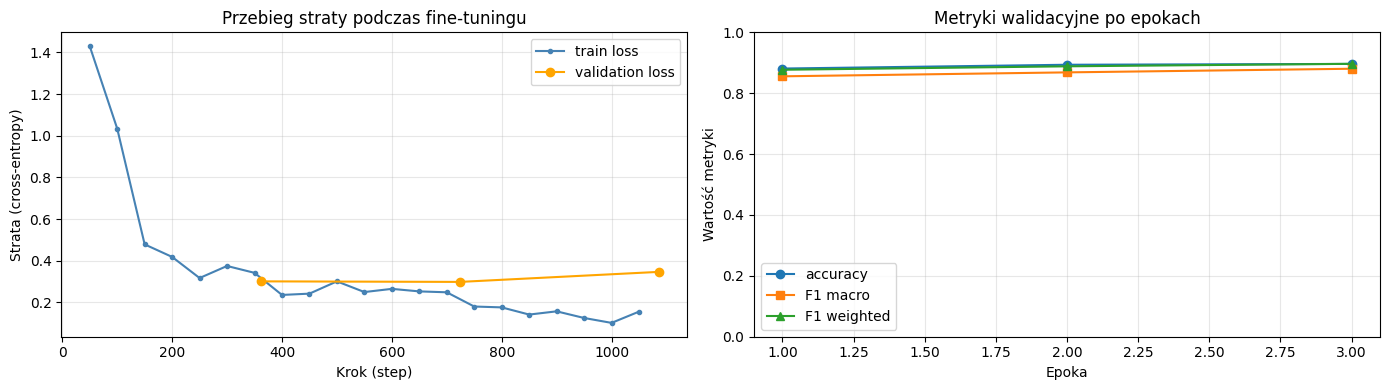

In [61]:
# Ekstrakcja historii z log_history
log = trainer.state.log_history

# Strata treningowa — logowana co `logging_steps`
train_loss = [(e['step'], e['loss']) for e in log if 'loss' in e and 'eval_loss' not in e]

# Metryki walidacyjne — logowane po epoce
eval_metrics = [e for e in log if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Wykres 1: strata treningowa
if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses, marker='.', color='steelblue', label='train loss')
if eval_metrics:
    eval_steps = [e['step'] for e in eval_metrics]
    eval_losses = [e['eval_loss'] for e in eval_metrics]
    axes[0].plot(eval_steps, eval_losses, marker='o', color='orange', label='validation loss')
axes[0].set_xlabel('Krok (step)')
axes[0].set_ylabel('Strata (cross-entropy)')
axes[0].set_title('Przebieg straty podczas fine-tuningu')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Wykres 2: metryki walidacyjne po epokach
if eval_metrics:
    epochs = [e['epoch'] for e in eval_metrics]
    axes[1].plot(epochs, [e['eval_accuracy'] for e in eval_metrics],
                 marker='o', label='accuracy')
    axes[1].plot(epochs, [e['eval_f1_macro'] for e in eval_metrics],
                 marker='s', label='F1 macro')
    axes[1].plot(epochs, [e['eval_f1_weighted'] for e in eval_metrics],
                 marker='^', label='F1 weighted')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('Wartość metryki')
    axes[1].set_title('Metryki walidacyjne po epokach')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 8. Ewaluacja na zbiorze testowym

Po treningu (i z załadowanym najlepszym checkpointem dzięki `load_best_model_at_end=True`) ewaluujemy model na zbiorze testowym — **tym samym**, na którym ewaluowaliśmy klasyczne modele w lab. 7.

In [62]:
# Predykcja na zbiorze testowym
predictions_output = trainer.predict(tokenized_dataset["test"])

y_pred_ids = np.argmax(predictions_output.predictions, axis=-1)
y_true_ids = predictions_output.label_ids

# Konwersja id → etykieta tekstowa (do raportu i porównania)
y_pred_labels = [id2label[i] for i in y_pred_ids]
y_true_labels = [id2label[i] for i in y_true_ids]

print("=" * 60)
print("HerBERT — Raport klasyfikacji (zbiór testowy)")
print("=" * 60)
print(classification_report(
    y_true_labels, y_pred_labels,
    target_names=[label_names_pl[l] for l in label_list],
    labels=label_list,
    zero_division=0,
))

HerBERT — Raport klasyfikacji (zbiór testowy)
              precision    recall  f1-score   support

   negatywny       0.91      0.92      0.92       300
   neutralny       0.98      1.00      0.99       117
   pozytywny       0.91      0.96      0.94       197
ambiwalentny       0.73      0.61      0.66       108

    accuracy                           0.90       722
   macro avg       0.88      0.87      0.88       722
weighted avg       0.90      0.90      0.90       722



In [63]:
# Zapisz metryki na później (do porównania z klasycznymi modelami)
herbert_metrics = {
    'accuracy': accuracy_score(y_true_labels, y_pred_labels),
    'f1_macro': f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0),
    'f1_weighted': f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0),
}
print("Metryki HerBERT na teście:")
for k, v in herbert_metrics.items():
    print(f"  {k}: {v:.4f}")

Metryki HerBERT na teście:
  accuracy: 0.9003
  f1_macro: 0.8774
  f1_weighted: 0.8970


## 8.1. Macierz pomyłek

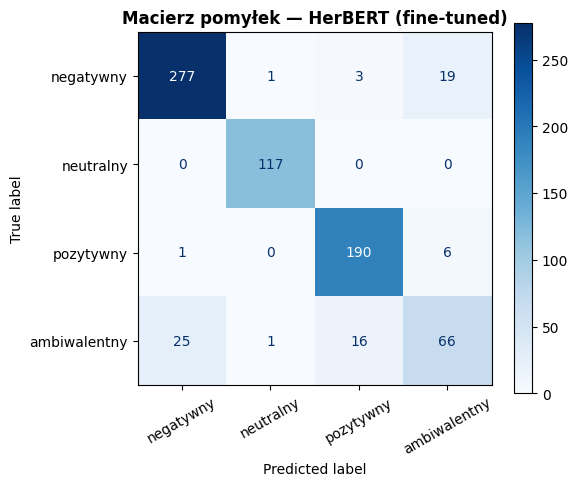

In [64]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=label_list)
display_labels = [label_names_pl[l] for l in label_list]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.set_title('Macierz pomyłek — HerBERT (fine-tuned)', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 9. Porównanie z klasycznym podejściem (lab. 7)

Dla sensownego porównania **odtwarzamy baseline z lab. 7** w tym samym notatniku — dzięki temu nie musimy przełączać się między zeszytami.

Trenujemy krótko trzy klasyczne modele (NB, SVM, LogReg) na tym samym podziale danych, a następnie zestawiamy wyniki.

In [65]:
# Import klasycznych narzędzi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
import re

def preprocess_text(text):
    """Preprocessing jak w lab. 7."""
    text = text.lower()
    text = re.sub(r'[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Przygotowanie danych dla modeli klasycznych
# UWAGA: musimy wziąć oryginalny dataset sprzed tokenizacji HF, bo tam jeszcze jest kolumna 'sentence'
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

# Normalizujemy etykiety na kanoniczne short labels (funkcja short_label() z sekcji 2.1),
# żeby wyniki były w tym samym formacie co HerBERT-a → raport klasyfikacji będzie czytelny
# i zgodny z label_list.
X_train_cls = df_train['sentence'].apply(preprocess_text).values
y_train_cls = df_train['target'].map(short_label).values
X_test_cls = df_test['sentence'].apply(preprocess_text).values
y_test_cls = df_test['target'].map(short_label).values

print(f"Zbiór treningowy (klasyczny): {len(X_train_cls)} przykładów")
print(f"Zbiór testowy:                {len(X_test_cls)} przykładów")
print(f"Unikatowe etykiety (po normalizacji): {sorted(set(y_train_cls))}")

Zbiór treningowy (klasyczny): 5783 przykładów
Zbiór testowy:                722 przykładów
Unikatowe etykiety (po normalizacji): ['amb', 'minus', 'plus', 'zero']


In [66]:
# Trening trzech modeli klasycznych (konfiguracja jak w lab. 7)
tfidf_kwargs = dict(max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

classic_models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_kwargs)),
        ('clf', MultinomialNB(alpha=1.0)),
    ]),
    'SVM (LinearSVC)': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_kwargs)),
        ('clf', LinearSVC(C=1.0, max_iter=10000, class_weight='balanced')),
    ]),
    'Regresja logistyczna': Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_kwargs)),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs')),
    ]),
}

classic_metrics = {}
for name, pipe in classic_models.items():
    pipe.fit(X_train_cls, y_train_cls)
    y_pred = pipe.predict(X_test_cls)
    classic_metrics[name] = {
        'accuracy': accuracy_score(y_test_cls, y_pred),
        'f1_macro': f1_score(y_test_cls, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test_cls, y_pred, average='weighted', zero_division=0),
    }
    print(f"  {name:25s} accuracy={classic_metrics[name]['accuracy']:.4f}, "
          f"F1 macro={classic_metrics[name]['f1_macro']:.4f}")

  Naive Bayes               accuracy=0.7950, F1 macro=0.7227
  SVM (LinearSVC)           accuracy=0.8255, F1 macro=0.7977
  Regresja logistyczna      accuracy=0.8006, F1 macro=0.7871


In [67]:
# Zestawienie wszystkich modeli — klasyczne vs transformer
comparison = dict(classic_metrics)
comparison['HerBERT (fine-tuned)'] = herbert_metrics

df_comparison = pd.DataFrame(comparison).T
df_comparison.columns = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']
print("=" * 70)
print("PORÓWNANIE: klasyczne ML vs HerBERT na PolEmo 2.0")
print("=" * 70)
print(df_comparison.round(4).to_string())

PORÓWNANIE: klasyczne ML vs HerBERT na PolEmo 2.0
                      Accuracy  F1 (macro)  F1 (weighted)
Naive Bayes             0.7950      0.7227         0.7661
SVM (LinearSVC)         0.8255      0.7977         0.8224
Regresja logistyczna    0.8006      0.7871         0.8054
HerBERT (fine-tuned)    0.9003      0.8774         0.8970


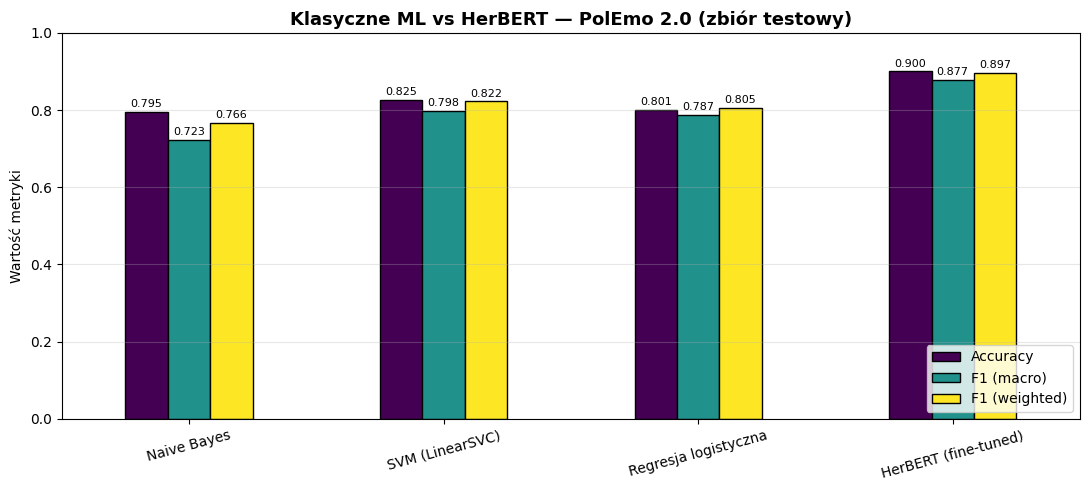

In [68]:
# Wizualizacja porównania
fig, ax = plt.subplots(figsize=(11, 5))
df_comparison.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Klasyczne ML vs HerBERT — PolEmo 2.0 (zbiór testowy)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Wartość metryki')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
# Dodanie wartości nad słupkami
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## 9.1. Interpretacja różnic

Spójrz na tabelę wyników. Typowo zobaczymy:

- **Przewaga HerBERT-a na F1 macro** — transformer lepiej radzi sobie z klasami mniejszościowymi (`neutralny`, `ambiwalentny`), które były trudne dla klasycznych modeli.
- **Klasa `ambiwalentny` jest najtrudniejsza dla wszystkich modeli** — to recenzje mieszające pozytywne i negatywne sygnały. Klasyczny model oparty na BoW/TF-IDF nie potrafi dobrze wyłapać tej semantyki (widzi tylko obecność słów, nie ich kontekstową interakcję). HerBERT dzięki self-attention widzi relacje między częściami zdania.
- **Koszt** — HerBERT wymaga GPU i kilku minut treningu. Naive Bayes trenuje się w sekundach na CPU.

Ta różnica ilustruje tezę z wykładu: **transformer opłaca się tam, gdzie liczy się zrozumienie kontekstu**. Dla wyraźnie nacechowanych recenzji (klasy `minus` i `plus`) oba podejścia są porównywalne — przewaga HerBERT-a pojawia się dopiero przy klasach wymagających głębszego rozumienia.

# 10. Predykcja na nowych tekstach

Użyjmy **tych samych** przykładowych zdań co w lab. 7 — łatwiej porównać zachowanie modeli.

In [69]:
# Te same teksty co w lab. 7
nowe_teksty = [
    "Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam gorąco!",
    "Hotel był brudny, jedzenie okropne, nigdy więcej.",
    "Wizyta u lekarza przebiegła bez problemów, nic szczególnego.",
    "Z jednej strony obsługa miła, ale pokoje wymagają remontu.",
    "Najgorszy hotel w jakim byłem. Karaluchy w łazience!",
    "Pani doktor poświęciła mi dużo czasu i dokładnie wszystko wyjaśniła.",
]

# Tokenizacja i predykcja (model jest w self.trainer.model)
inputs = tokenizer(nowe_teksty, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

model.eval()
with torch.no_grad():
    logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=-1)

print("Predykcje HerBERT na nowych tekstach:")
print("=" * 80)
for tekst, pred_id, p in zip(nowe_teksty, preds, probs):
    etykieta = label_names_pl[id2label[pred_id]]
    conf = p[pred_id]
    print(f"[{etykieta:>13s} {conf:.3f}]  {tekst}")

Predykcje HerBERT na nowych tekstach:
[    pozytywny 0.996]  Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam gorąco!
[    negatywny 0.995]  Hotel był brudny, jedzenie okropne, nigdy więcej.
[    pozytywny 0.914]  Wizyta u lekarza przebiegła bez problemów, nic szczególnego.
[ ambiwalentny 0.958]  Z jednej strony obsługa miła, ale pokoje wymagają remontu.
[    negatywny 0.996]  Najgorszy hotel w jakim byłem. Karaluchy w łazience!
[    pozytywny 0.995]  Pani doktor poświęciła mi dużo czasu i dokładnie wszystko wyjaśniła.


In [70]:
# Pełny rozkład prawdopodobieństw dla każdego tekstu (jak w lab. 7)
print("Rozkład prawdopodobieństwa klas:")
print("=" * 80)
for tekst, p in zip(nowe_teksty, probs):
    print(f"\nTekst: {tekst[:60]}...")
    for idx, prob in enumerate(p):
        nazwa = label_names_pl[id2label[idx]]
        bar = '█' * int(prob * 30)
        print(f"  {nazwa:>13s}: {prob:.3f} {bar}")

Rozkład prawdopodobieństwa klas:

Tekst: Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam g...
      negatywny: 0.001 
      neutralny: 0.001 
      pozytywny: 0.996 █████████████████████████████
   ambiwalentny: 0.001 

Tekst: Hotel był brudny, jedzenie okropne, nigdy więcej....
      negatywny: 0.995 █████████████████████████████
      neutralny: 0.001 
      pozytywny: 0.002 
   ambiwalentny: 0.002 

Tekst: Wizyta u lekarza przebiegła bez problemów, nic szczególnego....
      negatywny: 0.003 
      neutralny: 0.001 
      pozytywny: 0.914 ███████████████████████████
   ambiwalentny: 0.082 ██

Tekst: Z jednej strony obsługa miła, ale pokoje wymagają remontu....
      negatywny: 0.034 █
      neutralny: 0.004 
      pozytywny: 0.004 
   ambiwalentny: 0.958 ████████████████████████████

Tekst: Najgorszy hotel w jakim byłem. Karaluchy w łazience!...
      negatywny: 0.996 █████████████████████████████
      neutralny: 0.001 
      pozytywny: 0.002 
   ambiwalentny: 0.002 

Te

# 11. Analiza błędów

Spójrzmy, które przykłady HerBERT pomylił — to pozwala zrozumieć granice modelu.

In [71]:
# Tworzymy DataFrame z predykcjami i prawdami
errors_df = pd.DataFrame({
    'tekst': df_test['sentence'].values,
    'prawda': [label_names_pl[l] for l in y_true_labels],
    'predykcja': [label_names_pl[l] for l in y_pred_labels],
})
errors_df['poprawne'] = errors_df['prawda'] == errors_df['predykcja']

n_all = len(errors_df)
n_errors = (~errors_df['poprawne']).sum()
print(f"Błędne predykcje: {n_errors} / {n_all} ({n_errors/n_all*100:.1f}%)")
print()

# Najczęstsze typy pomyłek
print("Najczęstsze typy pomyłek (prawda → predykcja):")
pair_counts = (errors_df[~errors_df['poprawne']]
               .groupby(['prawda', 'predykcja']).size()
               .sort_values(ascending=False))
print(pair_counts.head(10).to_string())

Błędne predykcje: 72 / 722 (10.0%)

Najczęstsze typy pomyłek (prawda → predykcja):
prawda        predykcja   
ambiwalentny  negatywny       25
negatywny     ambiwalentny    19
ambiwalentny  pozytywny       16
pozytywny     ambiwalentny     6
negatywny     pozytywny        3
ambiwalentny  neutralny        1
negatywny     neutralny        1
pozytywny     negatywny        1


In [72]:
# Kilka przykładów błędów
print("Losowa próbka błędnych predykcji HerBERT:")
print("=" * 80)
sample_errors = errors_df[~errors_df['poprawne']].sample(min(5, n_errors), random_state=SEED)
for _, row in sample_errors.iterrows():
    print(f"PRAWDA: {row['prawda']:>13s}  |  PREDYKCJA: {row['predykcja']}")
    tekst = row['tekst']
    print(f"TEKST:  {tekst[:250]}{'...' if len(tekst) > 250 else ''}")
    print("-" * 80)

Losowa próbka błędnych predykcji HerBERT:
PRAWDA:  ambiwalentny  |  PREDYKCJA: negatywny
TEKST:  Niestety póki co komentarz neutralny . Pomimo obietnicy przesłania diety trzy dni po wizycie , po 8 dniach zero diety , zero kontaktu , brak odpowiedzi na wiadomości , smsy , telefony . Jest mi bardzo przykro , bo pani Olimpia zrobiła na mnie dobre w...
--------------------------------------------------------------------------------
PRAWDA:     pozytywny  |  PREDYKCJA: ambiwalentny
TEKST:  Dobre położenie : niedaleko do Tauron Areny , 20 - 25 minut spacerkiem do Rynku , komunikacja miejska przy hotelu . Bardzo miła i kompetentna obsługa . Duży wybór smacznych dań i dodatków na śniadanie . Trochę mniej banalny wystrój pokoi niż zwykle p...
--------------------------------------------------------------------------------
PRAWDA:     negatywny  |  PREDYKCJA: ambiwalentny
TEKST:  Lekarz przygotowany do wizyty ( zapoznał się z długa historia choroby przed naszym przyjściem ) . Miły , pomocny , z 

# 12. Dobór hiperparametrów — krótki eksperyment

Na wykładzie wspomniano typowe wartości:
- `learning_rate`: `2e-5`–`5e-5`
- `num_train_epochs`: 2–4

Poeksperymentujmy z **jedną** alternatywną konfiguracją — np. większym lr lub większą liczbą epok — żeby zobaczyć wpływ. Dla oszczędności czasu robimy to na **mniejszym zbiorze**.

> Pełny grid search (jak w lab. 7) tutaj byłby zbyt czasochłonny. Koncepcyjnie jest on realizowany przez `hyperparameter_search` w `Trainer` albo zewnętrznie (np. Optuna, Ray Tune).

In [73]:
# Funkcja pomocnicza: pełny fine-tune z podanymi parametrami
from transformers import set_seed
import inspect

# Detekcja API Trainer (jak w sekcji 7)
_uses_processing_class = 'processing_class' in inspect.signature(Trainer.__init__).parameters

def train_and_evaluate(learning_rate=2e-5, num_epochs=3, subset_size=None, tag="cfg"):
    """Trenuje świeży model z podanymi hiperparametrami i zwraca metryki na walidacji."""
    set_seed(SEED)

    # Opcjonalnie zmniejszamy zbiór treningowy dla szybkości
    train_ds = tokenized_dataset["train"]
    if subset_size is not None:
        train_ds = train_ds.shuffle(seed=SEED).select(range(subset_size))

    # Świeży model (żeby nie trenować na już dostrojonych wagach)
    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(label_list),
        id2label=id2label, label2id=label2id,
    )

    args = TrainingArguments(
        output_dir=f"./hp-{tag}",
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",                   # nie zapisujemy — oszczędność dysku
        fp16=torch.cuda.is_available(),
        logging_strategy="epoch",
        report_to="none",
        seed=SEED,
        disable_tqdm=True,                    # czystsze logi
    )

    trainer_kwargs = dict(
        model=m, args=args,
        train_dataset=train_ds,
        eval_dataset=tokenized_dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    if _uses_processing_class:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer

    tr = Trainer(**trainer_kwargs)
    tr.train()
    return tr.evaluate()

In [74]:
# Szybki eksperyment na ograniczonym zbiorze (2000 przykładów) — kilka minut łącznie
# Porównujemy dwie konfiguracje learning rate

print("Eksperyment z hiperparametrami (podzbiór 2000 przykładów, 2 epoki):\n")

configs = [
    {"learning_rate": 2e-5, "num_epochs": 2, "tag": "lr2e5"},
    {"learning_rate": 5e-5, "num_epochs": 2, "tag": "lr5e5"},
]

hp_results = {}
for cfg in configs:
    print(f"\n→ Konfiguracja: lr={cfg['learning_rate']:.0e}, epochs={cfg['num_epochs']}")
    metrics = train_and_evaluate(
        learning_rate=cfg['learning_rate'],
        num_epochs=cfg['num_epochs'],
        subset_size=2000,
        tag=cfg['tag'],
    )
    key = f"lr={cfg['learning_rate']:.0e}"
    hp_results[key] = {
        'accuracy': metrics['eval_accuracy'],
        'f1_macro': metrics['eval_f1_macro'],
    }
    print(f"  accuracy={metrics['eval_accuracy']:.4f}, F1 macro={metrics['eval_f1_macro']:.4f}")

print("\n" + "=" * 50)
print("Zestawienie wyników:")
print(pd.DataFrame(hp_results).T.round(4).to_string())

Eksperyment z hiperparametrami (podzbiór 2000 przykładów, 2 epoki):


→ Konfiguracja: lr=2e-05, epochs=2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly in

{'loss': '0.8207', 'grad_norm': '14.58', 'learning_rate': '1.12e-05', 'epoch': '1'}
{'eval_loss': '0.4353', 'eval_accuracy': '0.8409', 'eval_f1_macro': '0.8063', 'eval_f1_weighted': '0.8307', 'eval_precision_macro': '0.8351', 'eval_recall_macro': '0.798', 'eval_runtime': '3.267', 'eval_samples_per_second': '221.3', 'eval_steps_per_second': '7.04', 'epoch': '1'}
{'loss': '0.3281', 'grad_norm': '26.1', 'learning_rate': '8.889e-08', 'epoch': '2'}
{'eval_loss': '0.3326', 'eval_accuracy': '0.8714', 'eval_f1_macro': '0.8513', 'eval_f1_weighted': '0.8698', 'eval_precision_macro': '0.8537', 'eval_recall_macro': '0.8494', 'eval_runtime': '2.928', 'eval_samples_per_second': '246.9', 'eval_steps_per_second': '7.854', 'epoch': '2'}
{'train_runtime': '65.82', 'train_samples_per_second': '60.77', 'train_steps_per_second': '3.798', 'train_loss': '0.5744', 'epoch': '2'}
{'eval_loss': '0.3326', 'eval_accuracy': '0.8714', 'eval_f1_macro': '0.8513', 'eval_f1_weighted': '0.8698', 'eval_precision_macro': '

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly in

{'loss': '0.715', 'grad_norm': '22.4', 'learning_rate': '2.8e-05', 'epoch': '1'}
{'eval_loss': '0.381', 'eval_accuracy': '0.8492', 'eval_f1_macro': '0.8149', 'eval_f1_weighted': '0.8396', 'eval_precision_macro': '0.839', 'eval_recall_macro': '0.8076', 'eval_runtime': '3.425', 'eval_samples_per_second': '211.1', 'eval_steps_per_second': '6.716', 'epoch': '1'}
{'loss': '0.255', 'grad_norm': '16.38', 'learning_rate': '2.222e-07', 'epoch': '2'}
{'eval_loss': '0.3029', 'eval_accuracy': '0.8893', 'eval_f1_macro': '0.8704', 'eval_f1_weighted': '0.8872', 'eval_precision_macro': '0.8742', 'eval_recall_macro': '0.8677', 'eval_runtime': '3.092', 'eval_samples_per_second': '233.8', 'eval_steps_per_second': '7.438', 'epoch': '2'}
{'train_runtime': '69.74', 'train_samples_per_second': '57.36', 'train_steps_per_second': '3.585', 'train_loss': '0.485', 'epoch': '2'}
{'eval_loss': '0.3029', 'eval_accuracy': '0.8893', 'eval_f1_macro': '0.8704', 'eval_f1_weighted': '0.8872', 'eval_precision_macro': '0.87

**Wnioski:**
- Dla fine-tuningu BERT `2e-5` to zwykle bezpieczny wybór. Większe `5e-5` może być szybsze, ale bywa niestabilne.
- W prawdziwym projekcie warto zrobić mały grid: `{1e-5, 2e-5, 3e-5, 5e-5}` × `{2, 3, 4}` epoki — ale na pełnym zbiorze treningowym.
- Bardzo ważne: **seed ma wpływ** — różne losowe inicjalizacje głowy klasyfikacyjnej mogą dać wyniki różniące się o ~1 pp F1. Dla publikacji raportuje się średnią z kilku seedów.

# 13. Zapis modelu — publikacja i późniejsze użycie

Po fine-tuningu możemy zapisać model lokalnie lub opublikować na Hugging Face Hub.

In [75]:
# Zapis lokalny — wagi + tokenizer + konfiguracja
save_dir = "./herbert-polemo-final"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

import os
files = sorted(os.listdir(save_dir))
print(f"Model zapisany w: {save_dir}")
print("Zawartość katalogu:")
for f in files:
    size_mb = os.path.getsize(os.path.join(save_dir, f)) / 1e6
    print(f"  {f:30s} {size_mb:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model zapisany w: ./herbert-polemo-final
Zawartość katalogu:
  config.json                    0.0 MB
  model.safetensors              497.8 MB
  tokenizer.json                 3.7 MB
  tokenizer_config.json          0.0 MB
  training_args.bin              0.0 MB


In [76]:
# Ładowanie modelu z dysku i szybki test (tak jakbyśmy uruchomili notatnik od nowa)
from transformers import pipeline

loaded_pipe = pipeline(
    "text-classification",
    model=save_dir,
    tokenizer=save_dir,
    device=0 if torch.cuda.is_available() else -1,
)

test = loaded_pipe("Świetny produkt, dokładnie taki jak opisany!")
print("Predykcja z wczytanego modelu:")
print(test)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predykcja z wczytanego modelu:
[{'label': 'plus', 'score': 0.9951289892196655}]


## Ćwiczenie A: fine-tuning HerBERT na Allegro Reviews

**Zadanie:** Powtórz pipeline z tego notatnika na datasecie `allegro/klej-allegro-reviews` (ten sam, który był w lab. 7 jako ćwiczenie).

**Wskazówki:**
1. Kolumna tekstowa to `text`, etykieta to `rating` (wartości zmiennoprzecinkowe; przemapuj je na etykiety całkowite 0–4 lub zbinaryzuj: `rating < 3` → negatywny, `rating > 3` → pozytywny, odrzuć `rating == 3`).
2. Zbiór testowy nie ma etykiet → używaj `validation` do ewaluacji.
3. Porównaj wyniki z klasycznym TF-IDF + SVM z lab. 7.
4. Użyj tej samej konfiguracji `TrainingArguments`, ale rozważ `num_train_epochs=2` (zbiór jest większy).

In [77]:
# Ćwiczenie A — szkielet

# TODO: załaduj dataset
# dataset_allegro = load_dataset("allegro/klej-allegro-reviews")

# TODO: zbinaryzuj lub zmapuj 'rating' na etykiety całkowite
#       np. def map_rating(r): return 0 if r < 3 else (1 if r > 3 else None)

# TODO: tokenizacja (jak w sekcji 4)

# TODO: model = AutoModelForSequenceClassification.from_pretrained(
#           "allegro/herbert-base-cased", num_labels=<liczba klas>)

# TODO: TrainingArguments, Trainer, trener.train(), trener.evaluate()

# TODO: porównaj wyniki z klasycznym TF-IDF + SVM z lab. 7


## Ćwiczenie B: wpływ rozmiaru zbioru treningowego

**Zadanie:** Zbadaj, jak jakość fine-tuningu zależy od liczby przykładów treningowych. To jeden z kluczowych argumentów „kiedy transformer vs klasyczny ML" z wykładu.

**Instrukcje:**
1. Wybierz podzbiory zbioru PolEmo 2.0 o rozmiarach: 100, 500, 1000, 2000, pełny zbiór.
2. Dla każdego rozmiaru fine-tunuj HerBERT (2 epoki, `lr=2e-5`).
3. Dla **tych samych** podzbiorów wytrenuj klasyczny TF-IDF + SVM.
4. Narysuj wykres: rozmiar zbioru (oś X) vs F1 macro (oś Y), z dwiema krzywymi (HerBERT, SVM).

**Oczekiwana obserwacja:** dla małych zbiorów (~100–500) klasyczny model może być lepszy (mniej parametrów do dopasowania). HerBERT zaczyna wygrywać około 1000–2000 przykładów i dalej rośnie.

In [78]:
# Ćwiczenie B — szkielet

# rozmiary = [100, 500, 1000, 2000, len(tokenized_dataset['train'])]
# wyniki_herbert = {}
# wyniki_svm = {}

# for n in rozmiary:
#     # HerBERT
#     sub = tokenized_dataset['train'].shuffle(seed=SEED).select(range(n))
#     # ... Trainer ...
#     wyniki_herbert[n] = metrics['eval_f1_macro']
#
#     # SVM
#     df_sub = df_train.sample(n, random_state=SEED)
#     pipe.fit(...)
#     wyniki_svm[n] = f1_score(..., average='macro')

# Narysuj dwie krzywe na jednym wykresie
